#### Its same as previous, i want to add evaluation as extra step(node)

START -> topic -> OUTLINE -> BLOG GENERATION -> EVALUATE THE BLOG BASED ON GIVEN OUTLINE (INT SCORE) -> END

In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv

In [2]:
load_dotenv()

model = ChatOpenAI()

In [3]:
# changing as ill be using deepseek
import os

model = ChatOpenAI(
    model="deepseek-v4-flash",                         # Use "deepseek-reasoner" for DeepSeek-R1
    base_url="https://api.deepseek.com",
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    temperature=0.7, 
    extra_body={"thinking": {"type": "disabled"}},       # turning thinking/reasoning off 
    # reasoning_effort= 'low'  
)

In [4]:
# creating state using pydantic not typeddict
from pydantic import BaseModel

# class BlogState(BaseModel):   # was facing some issue while invoking the workflow - ANS: needs model_fields, not state['key'] its state.key
class BlogState(TypedDict):
    topic: str
    outline: str
    blog: str
    score: int

In [5]:
# creating graph
graph = StateGraph(BlogState)
graph

#### Creating helper functions for below graph nodes

In [ ]:
from langchain_core.prompts import PromptTemplate

def outline_fn(state: BlogState) -> BlogState:
    topic = state['topic']

    # prompt = PromptTemplate.from_template("Write a outline skeleton in 3 points (each consists of 2 subpoints) for the topic - {topic}")
    # chain = prompt | model
    # answer = chain.invoke({'topic': topic}).content
    
    # OR simply,
    prompt = f"Write a outline skeleton in 3 points (each consists of 2 subpoints) for the topic - {topic}" #im confused here a bit
    answer = model.invoke(prompt).content

    state['outline'] = answer
    # return {"outline": answer}    # langgraph recommends this
    return state

In [7]:
def blog_generation_fn(state: BlogState) -> BlogState:
    # topic = state['topic']    # not guiding with topic intentionally
    outline = state['outline']
    prompt = f"Write a blog under 150 words total which follows outline {outline}"
    answer = model.invoke(prompt).content

    state['blog'] = answer
    return state

In [8]:
def evaluator_fn(state: BlogState) -> BlogState:
    topic = state['topic']    # not guiding with topic intentionally
    blog = state['blog']

    prompt = f"""Rate this blog out of 10. Reply with ONLY a single integer, nothing else.
    
    Like if you think the blog is approx 6.7/10 just give answer as 7 .

    Blog topic: {topic}
    
    Blog:
    {blog}"""

    answer = model.invoke(prompt).content
    score = int(answer.strip())
    state['score'] = score
    return state

In [9]:
# adding nodes, edges
# del graph -> if you need to rerun this

graph.add_node(node='outline',          action=outline_fn        )
graph.add_node(node='blog_generation',  action=blog_generation_fn)
graph.add_node(node='evaluator',        action=evaluator_fn      )


graph.add_edge(start_key=START, end_key='outline')    # edge means connects two nodes
graph.add_edge(start_key='outline', end_key='blog_generation')
graph.add_edge(start_key='blog_generation', end_key='evaluator')
graph.add_edge(start_key='evaluator', end_key=END)

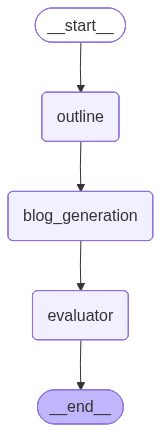

In [10]:
workflow = graph.compile()
workflow

In [ ]:
# here why initial_state , final_state ? state is same all along right?? ANS: purely stylistic 

final_state = workflow.invoke({'topic':'AI consuming natural resources violently'})
final_state

{'topic': 'AI consuming natural resources violently',
 'outline': 'Here is a 3-point outline skeleton on the topic of AI consuming natural resources violently, with each point containing two subpoints.\n\n**I. The Physical Footprint: Hardware Production and Raw Material Extraction**\n    A. **Conflict Minerals and Mining:** The manufacturing of AI-specific chips (GPUs, TPUs) relies heavily on rare earth elements and minerals (e.g., lithium, cobalt, tantalum), whose extraction often involves violent conflict, environmental devastation, and exploitative labor in regions like the Democratic Republic of Congo.\n    B. **Supply Chain Violence:** The global logistics required to move these raw materials (shipping, trucking, refining) generate massive carbon emissions and contribute to geopolitical tensions over resource control, effectively financing and fueling regional instability.\n\n**II. The Operational Violence: Energy Consumption and Environmental Collapse**\n    A. **Colossal Energy 

In [13]:
print(final_state['score'])

8


#### YAY!! Did it